# <span style="color:blue">PART 2: REST API INTEGRATION</span>


---
## 2.1 Understanding APIs: The Restaurant Analogy

Imagine a **restaurant**:

| Concept | API Equivalent |
|---|---|
| 🍳 Kitchen | Server with data |
| 📋 Menu | API documentation |
| 🧑‍🍳 Waiter | API endpoints |
| 📝 Your order | HTTP request |
| 🍽️ Your food | HTTP response |

> You **don't** go into the kitchen (database). You tell the waiter what you want, and they bring it to you.

---

### <span style="color:blue">HTTP Methods = Actions</span>

| Method | Meaning | Description |
|---|---|---|
| **`GET`** | "Show me the menu" | Retrieve data |
| **`POST`** | "I want to order this" | Create new data |
| **`PUT`** | "Change my entire order" | Replace data |
| **`PATCH`** | "Add extra cheese" | Update part of data |
| **`DELETE`** | "Cancel my order" | Remove data |

---

### <span style="color:blue">Status Codes = Kitchen's Response</span>

| Code | Message | Meaning |
|---|---|---|
| **200** | OK | "Here's your food!" |
| **201** | Created | "Order placed successfully!" |
| <span style="color:red">**400**</span> | Bad Request | "That's not on the menu" |
| <span style="color:red">**401**</span> | Unauthorized | "You need to pay first" |
| <span style="color:red">**404**</span> | Not Found | "We don't have that dish" |
| <span style="color:red">**429**</span> | Too Many Requests | "You're ordering too fast!" |
| <span style="color:red">**500**</span> | Server Error | "Kitchen is on fire" |

---
## 2.2 Real Example: GitHub API

**GitHub** provides free APIs to access public repository data. Let's explore!

> 📌 We use the `requests` library to make HTTP calls and `pandas` to work with the data.

In [3]:
import requests
import pandas as pd
import json
from datetime import datetime


# Example 1: Get repository information
def get_repo_info(owner, repo):
    """
    Fetch information about a GitHub repository.

    Args:
        owner: Repository owner (e.g., 'pandas-dev')
        repo: Repository name (e.g., 'pandas')

    Returns:
        dict: Repository information
    """
    # API endpoint - GitHub's REST API base URL + path to specific repo
    url = f'https://api.github.com/repos/{owner}/{repo}'

    # Make GET request to the API endpoint
    response = requests.get(url)

    # Check status code to determine if request succeeded
    print(f"Status Code: {response.status_code}")
    print(f"Response Headers:")
    for key, value in list(response.headers.items())[:5]:
        print(f"  {key}: {value}")

    # Parse JSON response only if request was successful
    if response.status_code == 200:
        data = response.json()

        # Extract only the relevant fields we care about
        repo_info = {
            'name': data['name'],
            'full_name': data['full_name'],
            'description': data['description'],
            'stars': data['stargazers_count'],
            'forks': data['forks_count'],
            'watchers': data['watchers_count'],
            'open_issues': data['open_issues_count'],
            'language': data['language'],
            'created_at': data['created_at'],
            'updated_at': data['updated_at'],
            'size': data['size'],
            'license': data['license']['name'] if data['license'] else 'No license',
        }
        return repo_info
    else:
        print(f"Error: {response.status_code}")
        return None


# Try it!
repo_info = get_repo_info('pandas-dev', 'pandas')

if repo_info:
    print("\n=== Repository Information ===")
    for key, value in repo_info.items():
        print(f"{key}: {value}")

Status Code: 200
Response Headers:
  Date: Mon, 02 Mar 2026 12:38:14 GMT
  Content-Type: application/json; charset=utf-8
  Cache-Control: public, max-age=60, s-maxage=60
  Vary: Accept,Accept-Encoding, Accept, X-Requested-With
  ETag: W/"24d6ec2432f9b98d33e93caf10667fe126caf9bc920999b1b30a4f050a948828"

=== Repository Information ===
name: pandas
full_name: pandas-dev/pandas
description: Flexible and powerful data analysis / manipulation library for Python, providing labeled data structures similar to R data.frame objects, statistical functions, and much more
stars: 48013
forks: 19711
watchers: 48013
open_issues: 3693
language: Python
created_at: 2010-08-24T01:37:33Z
updated_at: 2026-03-02T11:36:52Z
size: 383549
license: BSD 3-Clause "New" or "Revised" License


### Expected Output:
```
Status Code: 200
Response Headers:
  Content-Type: application/json
  X-RateLimit-Limit: 60
  X-RateLimit-Remaining: 59
  ...

=== Repository Information ===
name: pandas
full_name: pandas-dev/pandas
description: Flexible and powerful data analysis / manipulation library for Python
stars: 43256
forks: 17843
...
```

---

### <span style="color:blue">Understanding the Response</span>

An **HTTP Response** has 3 parts:

```
1. Status Line:   HTTP/1.1 200 OK

2. Headers:
   Content-Type: application/json
   X-RateLimit-Limit: 60        <-- Max requests per hour
   X-RateLimit-Remaining: 59    <-- Requests left

3. Body (JSON):
   {
     "name": "pandas",
     "stars": 43256,
     ...
   }
```

---
## 2.3 Handling Authentication

Many APIs require **authentication** to:
1. Track usage
2. Prevent abuse
3. Provide personalized data

---

### <span style="color:blue">Types of Authentication</span>

#### **Type 1: API Key in Header** *(Most Common)*

In [4]:
import os
from dotenv import load_dotenv  # pip install python-dotenv

# Load API key from .env file (keeps secrets out of your code)
load_dotenv()

api_key = os.getenv('GITHUB_TOKEN')

# Add the token to request headers for authentication
headers = {
    'Authorization': f'Bearer {api_key}',  # Token-based auth
    'Accept': 'application/vnd.github.v3+json',  # Tell server what format we want
    'User-Agent': 'Library-Tutorial-App',  # Identify your app
}

url = 'https://api.github.com/repos/pandas-dev/pandas'
response = requests.get(url, headers=headers)

#### Create a `.env` file in your project directory:

```
GITHUB_TOKEN=ghp_your_token_here
OPENWEATHER_KEY=your_key_here
```

#### <span style="color:red">⚠️ Why `.env`?</span>
- **Never** hardcode secrets in code!
- Different keys for dev/production
- Keeps secrets out of version control

#### Add to `.gitignore`:
```
.env
*.env
```

---

#### **Type 2: API Key in Query Parameters**

In [5]:
# Example: OpenWeather API uses key as a query parameter
api_key = os.getenv('OPENWEATHER_KEY')

# Parameters are automatically appended to the URL as ?q=Cairo&appid=...&units=metric
params = {
    'q': 'Cairo',
    'appid': api_key,
    'units': 'metric',  # Celsius instead of Kelvin
}

response = requests.get(
    'https://api.openweathermap.org/data/2.5/weather', params=params
)

#### **Type 3: OAuth** *(Complex but Secure)*

In [6]:
# OAuth flow (simplified):
# 1. User authorizes your app
# 2. You get an access token
# 3. Use token for requests
# This is beyond our scope but good to know!

---
## <span style="color:blue">2.4 Advanced: Pagination</span>

**Problem**: API returns 100 results, but there are **10,000!**

**Solution**: **Pagination** — fetch data in multiple pages, just like a book.

### <span style="color:blue">Pagination Strategies</span>

**1. Page-based (GitHub):**
```
/repos?page=1&per_page=100
/repos?page=2&per_page=100
```

**2. Offset-based:**
```
/repos?offset=0&limit=100
/repos?offset=100&limit=100
```

**3. Cursor-based** *(most efficient)*:
```
/repos?cursor=abc123
/repos?cursor=def456

Response includes next cursor:
{
  "data": [...],
  "next_cursor": "def456"
}
```

In [7]:
import time


def get_all_repos(org_name, max_pages=None):
    """
    Fetch all repositories for an organization using pagination.
    GitHub API returns 30 repos per page by default.
    """
    all_repos = []
    page = 1

    while True:
        # Check if we've reached max_pages (useful for testing/limiting)
        if max_pages and page > max_pages:
            break

        print(f"Fetching page {page}...")

        # Add page parameter to tell the API which chunk of results we want
        params = {'page': page, 'per_page': 100}  # Max allowed by GitHub

        url = f'https://api.github.com/orgs/{org_name}/repos'
        response = requests.get(url, params=params)

        if response.status_code != 200:
            print(f"Error: {response.status_code}")
            break

        data = response.json()

        # If no data returned, we've gone past the last page
        if not data or len(data) == 0:
            print("No more results!")
            break

        all_repos.extend(data)
        page += 1

        # Be polite - wait between requests to avoid rate limiting
        time.sleep(0.5)

    return all_repos


# Example: Get all pandas-dev repos (limit to 3 pages for demo)
repos = get_all_repos('pandas-dev', max_pages=3)
print(f"\nFetched {len(repos)} repositories")

# Convert list of dicts to a clean DataFrame
df = pd.DataFrame(
    [
        {
            'name': repo['name'],
            'stars': repo['stargazers_count'],
            'language': repo['language'],
            'description': repo['description'],
        }
        for repo in repos
    ]
)

print("\nTop 10 by Stars:")
print(df.sort_values('stars', ascending=False).head(10))

Fetching page 1...
Fetching page 2...
No more results!

Fetched 15 repositories

Top 10 by Stars:
                  name  stars          language  \
0               pandas  48013            Python   
9         pandas-stubs    308            Python   
1    pandas-governance     36              None   
2       pandas-msgpack     24            Python   
7  pandas-user-surveys     10  Jupyter Notebook   
8    pandas-dev-flaker     10            Python   
5          pandas-blog      8            Python   
3        pandas-compat      7            Python   
4       pandas-release      7            Python   
6              .github      3              None   

                                         description  
0  Flexible and powerful data analysis / manipula...  
9                       Public type stubs for pandas  
1  Project governance documents for the pandas Pr...  
2                                     Pandas Msgpack  
7                                               None  
8         

---
## 2.5 Rate Limiting & Retry Logic

<span style="color:red">**Problem**</span>: APIs limit requests to prevent abuse.

### GitHub Rate Limits:
- **Unauthenticated**: `60` requests/hour
- **Authenticated**: `5,000` requests/hour

---

### <span style="color:blue">Custom Rate Limiter Class</span>

In [8]:
import time
from datetime import datetime


class RateLimiter:
    """
    Smart rate limiter that tracks API usage.
    Uses a sliding time window to count recent requests.
    """

    def __init__(self, max_requests=60, time_window=3600):
        """
        Args:
            max_requests: Maximum requests allowed in the time window
            time_window: Time window in seconds (3600 = 1 hour)
        """
        self.max_requests = max_requests
        self.time_window = time_window
        self.requests = []  # List of timestamps of past requests

    def wait_if_needed(self):
        """Wait if we've hit the rate limit before making a new request."""
        now = time.time()

        # Remove old timestamps outside the sliding time window
        self.requests = [
            req_time for req_time in self.requests if now - req_time < self.time_window
        ]

        # If we've used up our quota, sleep until the oldest request expires
        if len(self.requests) >= self.max_requests:
            oldest_request = self.requests[0]
            sleep_time = self.time_window - (now - oldest_request)
            if sleep_time > 0:
                print(
                    f"⏰ Rate limit reached. Sleeping for {sleep_time:.1f} seconds..."
                )
                time.sleep(sleep_time)
            self.requests = []  # Clear after sleeping

        # Record the timestamp of this new request
        self.requests.append(now)


# Usage: 10 requests per minute limit
limiter = RateLimiter(max_requests=10, time_window=60)

url = 'https://api.github.com/repos/pandas-dev/pandas'
for i in range(15):
    limiter.wait_if_needed()  # Automatically pauses if limit is hit
    response = requests.get(url)
    print(f"Request {i+1} completed")

Request 1 completed
Request 2 completed
Request 3 completed
Request 4 completed
Request 5 completed
Request 6 completed
Request 7 completed
Request 8 completed
Request 9 completed
Request 10 completed
⏰ Rate limit reached. Sleeping for 51.7 seconds...
Request 11 completed
Request 12 completed
Request 13 completed
Request 14 completed
Request 15 completed


### <span style="color:blue">Checking API Limits from Headers</span>

In [9]:
def check_rate_limit(response):
    """
    Check rate limit info from response headers.
    GitHub includes rate limit details in every response.
    """
    if 'X-RateLimit-Limit' in response.headers:
        limit = int(response.headers['X-RateLimit-Limit'])
        remaining = int(response.headers['X-RateLimit-Remaining'])
        reset_timestamp = int(response.headers['X-RateLimit-Reset'])
        reset_time = datetime.fromtimestamp(reset_timestamp)

        print(f"Rate Limit: {remaining}/{limit}")
        print(f"Resets at: {reset_time}")

        # Warn when running low on available requests
        if remaining < 10:
            print("⚠️ Warning: Low on API requests!")

        return remaining
    return None


url = 'https://api.github.com/repos/pandas-dev/pandas'
response = requests.get(url)
check_rate_limit(response)

Rate Limit: 39/60
Resets at: 2026-03-02 15:16:38


39

### <span style="color:blue">Automatic Retry with Exponential Backoff</span>

**What is Exponential Backoff?**

Instead of hammering the server after a failure, we **wait progressively longer** between retries:

```
Attempt 1: Fails → Wait  1 second
Attempt 2: Fails → Wait  2 seconds
Attempt 3: Fails → Wait  4 seconds
Attempt 4: Fails → Wait  8 seconds
Attempt 5: Success! ✅
```

In [10]:
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry


def create_robust_session():
    """
    Create requests session with automatic retry logic.
    The session will automatically retry failed requests using exponential backoff.
    """
    session = requests.Session()

    # Define retry strategy - what to retry, how many times, and how long to wait
    retry_strategy = Retry(
        total=5,  # Maximum number of retries
        backoff_factor=1,  # Wait 0, 1, 2, 4, 8 seconds between retries
        status_forcelist=[429, 500, 502, 503, 504],  # Retry on these status codes
        allowed_methods=["HEAD", "GET", "OPTIONS", "POST"],  # Methods to retry
    )

    # Mount the retry adapter for both http and https
    adapter = HTTPAdapter(max_retries=retry_strategy)
    session.mount("http://", adapter)
    session.mount("https://", adapter)

    return session


# Usage - just use this session like you would requests.get()
session = create_robust_session()
response = session.get('https://api.github.com/repos/pandas-dev/pandas')
print(f"Status: {response.status_code}")

Status: 200


---
## 2.6 Error Handling & Logging

**Robust code** anticipates failures and records what happened for debugging.

In [11]:
import logging
from datetime import datetime

# Configure logging to write to both a file AND the console
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('api_requests.log'),  # Saves to disk
        logging.StreamHandler(),  # Also print to console
    ],
)

logger = logging.getLogger(__name__)


def fetch_with_error_handling(url, max_retries=3):
    """
    Robust API fetch with comprehensive error handling.
    Handles: timeouts, connection errors, rate limits, server errors, bad JSON.
    """
    for attempt in range(max_retries):
        try:
            logger.info(f"Attempt {attempt + 1}/{max_retries}: GET {url}")
            response = requests.get(url, timeout=10)  # Don't wait more than 10 seconds

            # Handle each status code type differently
            if response.status_code == 200:
                logger.info(f" Success: {url}")
                # logger.info(f"✓ Success: {url}") 3lamt s7 kant 3mlaly error 
                return response.json()

            elif response.status_code == 404:
                logger.error(f"✗ Not Found: {url}")
                return None  # No point retrying - resource doesn't exist

            elif response.status_code == 429:
                # Server tells us how long to wait in the Retry-After header
                retry_after = int(response.headers.get('Retry-After', 60))
                logger.warning(f"Rate limited. Waiting {retry_after}s...")
                time.sleep(retry_after)
                continue

            elif response.status_code >= 500:
                # Server error - retry with exponential backoff
                logger.error(f"Server error ({response.status_code}). Retrying...")
                time.sleep(2**attempt)  # 1, 2, 4 seconds
                continue

            else:
                logger.error(f"HTTP {response.status_code}: {url}")
                response.raise_for_status()

        except requests.exceptions.Timeout:
            logger.warning(f"Timeout on attempt {attempt + 1}")
            if attempt < max_retries - 1:
                time.sleep(2**attempt)

        except requests.exceptions.ConnectionError as e:
            logger.error(f"Connection error: {e}")
            if attempt < max_retries - 1:
                time.sleep(2**attempt)

        except json.JSONDecodeError:
            logger.error("Invalid JSON response")  # Server returned non-JSON
            return None

        except Exception as e:
            logger.error(f"Unexpected error: {e}")
            return None

    logger.error(f"Failed after {max_retries} attempts")
    return None


# Usage
data = fetch_with_error_handling('https://api.github.com/repos/python/cpython')
if data:
    print(f"Repo: {data['full_name']}, Stars: {data['stargazers_count']}")

2026-03-02 14:39:25,813 - __main__ - INFO - Attempt 1/3: GET https://api.github.com/repos/python/cpython
2026-03-02 14:39:26,834 - __main__ - INFO -  Success: https://api.github.com/repos/python/cpython


Repo: python/cpython, Stars: 71776


**Expected Log Output:**
```
2024-03-15 10:30:45 - __main__ - INFO - Attempt 1/3: GET https://api.github.com/...
2024-03-15 10:30:46 - __main__ - INFO - ✓ Success: https://api.github.com/...
```

---
## 2.7 Building a Reusable API Client

Combining everything we've learned into a **clean, professional `GitHubAPI` class** that can be reused across projects.

In [12]:
class GitHubAPI:
    """
    Reusable GitHub API client with all best practices:
    - Session management with retry logic
    - Rate limiting
    - Authentication via token
    - Logging
    """

    def __init__(self, token=None):
        self.base_url = 'https://api.github.com'
        self.session = self._create_session()  # Robust session with retries
        self.rate_limiter = RateLimiter(
            max_requests=5000, time_window=3600
        )  # Authenticated limits

        # Add authentication token if provided
        if token:
            self.session.headers.update({'Authorization': f'Bearer {token}'})

        # Always set these headers for proper API communication
        self.session.headers.update(
            {
                'Accept': 'application/vnd.github.v3+json',
                'User-Agent': 'Library-Tutorial/1.0',
            }
        )

        self.logger = logging.getLogger(self.__class__.__name__)

    def _create_session(self):
        """Create session with retry logic (private method)."""
        session = requests.Session()
        retry_strategy = Retry(
            total=3, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504]
        )
        adapter = HTTPAdapter(max_retries=retry_strategy)
        session.mount("http://", adapter)
        session.mount("https://", adapter)
        return session

    def get(self, endpoint, params=None):
        """Make GET request with rate limiting."""
        self.rate_limiter.wait_if_needed()  # Respect rate limits
        url = f"{self.base_url}/{endpoint.lstrip('/')}"

        try:
            response = self.session.get(url, params=params, timeout=10)
            response.raise_for_status()  # Raises exception for 4xx/5xx
            self.logger.info(f"GET {endpoint} - Status: {response.status_code}")

            # Peek at remaining rate limit with each response
            remaining = check_rate_limit(response)
            return response.json()

        except Exception as e:
            self.logger.error(f"Error fetching {endpoint}: {e}")
            raise

    def get_repo(self, owner, repo):
        """Get repository information."""
        return self.get(f'/repos/{owner}/{repo}')

    def get_user_repos(self, username):
        """Get all repositories for a user."""
        return self.get(f'/users/{username}/repos', params={'per_page': 100})

    def search_repos(self, query, language=None, min_stars=None):
        """
        Search repositories.

        Args:
            query: Search query string
            language: Filter by programming language
            min_stars: Minimum stars required

        Returns:
            list: Repository results
        """
        # Build search query by combining filters with spaces
        q_parts = [query]
        if language:
            q_parts.append(f"language:{language}")
        if min_stars:
            q_parts.append(f"stars:>={min_stars}")

        q = ' '.join(q_parts)
        results = self.get('/search/repositories', params={'q': q})
        return results['items']

    def to_dataframe(self, repos):
        """Convert repository list to DataFrame for analysis."""
        data = []
        for repo in repos:
            data.append(
                {
                    'name': repo['name'],
                    'full_name': repo['full_name'],
                    'description': repo.get('description'),
                    'stars': repo['stargazers_count'],
                    'forks': repo['forks_count'],
                    'language': repo.get('language'),
                    'created_at': repo['created_at'],
                    'updated_at': repo['updated_at'],
                }
            )
        return pd.DataFrame(data)


# ============================
# Usage Examples
# ============================

api = GitHubAPI(token=os.getenv('GITHUB_TOKEN'))  # Authenticated (5000 req/hr)

# Get a single repository
repo = api.get_repo('pandas-dev', 'pandas')
print(f"Stars: {repo['stargazers_count']}")

# Search repositories with filters
python_repos = api.search_repos('machine learning', language='python', min_stars=1000)
df = api.to_dataframe(python_repos)
print(df.head())

2026-03-02 14:39:27,913 - GitHubAPI - INFO - GET /repos/pandas-dev/pandas - Status: 200


Rate Limit: 36/60
Resets at: 2026-03-02 15:16:38
Stars: 48013


2026-03-02 14:39:29,045 - GitHubAPI - INFO - GET /search/repositories - Status: 200


Rate Limit: 9/10
Resets at: 2026-03-02 14:40:27
⚠️ Warning: Low on API requests!
                        name                                 full_name  \
0   awesome-machine-learning     josephmisiti/awesome-machine-learning   
1            MachineLearning                      wepe/MachineLearning   
2           Machine-Learning             Jack-Cherish/Machine-Learning   
3     MachineLearning_Python          lawlite19/MachineLearning_Python   
4  machine_learning_examples  lazyprogrammer/machine_learning_examples   

                                         description  stars  forks language  \
0  A curated list of awesome Machine Learning fra...  71784  15326   Python   
1           Basic Machine Learning and Deep Learning   5647   3213   Python   
2  :zap:机器学习实战（Python3）：kNN、决策树、贝叶斯、逻辑回归、SVM、线性回归...  10232   5110   Python   
3                                     机器学习算法python实现   8362   2509   Python   
4  A collection of machine learning examples and ...   8827   6447   Python   


---
## 2.8 Working with Different Response Formats

APIs don't always respond with JSON — here's how to handle the two most common formats.

---

### <span style="color:blue">JSON (Most Common)</span>

In [13]:
# Simple JSON - direct parsing
response = requests.get('https://api.github.com/repos/pandas-dev/pandas')
data = response.json()

# Nested JSON - requires flattening for DataFrame use
data = {
    "user": {
        "name": "Ahmed",
        "address": {"city": "Cairo", "country": "Egypt"},
        "repositories": [
            {"name": "repo1", "stars": 10},
            {"name": "repo2", "stars": 25},
        ],
    }
}

# Flatten nested JSON with json_normalize - great for deeply nested responses
df = pd.json_normalize(
    data['user']['repositories'], sep='_'  # Use underscore to separate nested keys
)
print("Simple flatten:")
print(df)

# Or access nested data with record_path and meta
# record_path = which nested list to expand as rows
# meta = which parent fields to carry along as columns
df = pd.json_normalize(
    data,
    record_path=['user', 'repositories'],
    meta=[['user', 'name'], ['user', 'address', 'city']],
    meta_prefix='user_',
)
print("\nWith metadata:")
print(df)

Simple flatten:
    name  stars
0  repo1     10
1  repo2     25

With metadata:
    name  stars user_user.name user_user.address.city
0  repo1     10          Ahmed                  Cairo
1  repo2     25          Ahmed                  Cairo


### <span style="color:blue">XML</span>

Some older APIs (e.g., government data, RSS feeds) return XML instead of JSON.

In [14]:
import xml.etree.ElementTree as ET

# Sample XML response from an API
xml_string = """
<library>
  <book id="1">
    <title>Python Basics</title>
    <author>John Doe</author>
    <year>2023</year>
  </book>
  <book id="2">
    <title>Data Science</title>
    <author>Jane Smith</author>
    <year>2024</year>
  </book>
</library>
"""

# Parse the XML string into a tree structure
root = ET.fromstring(xml_string)

# Navigate the tree and extract data into a list of dicts
books = []
for book in root.findall(
    './/book'
):  # './/book' finds all <book> tags anywhere in the tree
    books.append(
        {
            'id': book.get('id'),  # Get XML attribute
            'title': book.find('title').text,  # Get text content of child tag
            'author': book.find('author').text,
            'year': int(book.find('year').text),
        }
    )

# Convert to DataFrame for easy analysis
df = pd.DataFrame(books)
print(df)

  id          title      author  year
0  1  Python Basics    John Doe  2023
1  2   Data Science  Jane Smith  2024


---
## <span style="color:blue">2.9 Graded Exercise 2: GitHub Repository Analysis</span>

**Scenario**: Analyze GitHub repositories to understand popular technologies.

---

### 📋 Task 1: Repository Information *(15 points)*

**1.1** *(5 points)* Fetch information for these repositories:
- `tensorflow/tensorflow`
- `pytorch/pytorch`
- `scikit-learn/scikit-learn`

Create a **DataFrame** with columns: `name`, `stars`, `forks`, `language`, `open_issues`, `created_date`

Save as: **`task1_github.csv`**

In [15]:
def task1_fetch_repos():
    """
    Fetch repository information for major ML frameworks.
    Returns a DataFrame with key metrics.
    """
    repos = ['tensorflow/tensorflow', 'pytorch/pytorch', 'scikit-learn/scikit-learn']
    all_repos = []
    for repo in repos:
        url = f'https://api.github.com/repos/{repo}'
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()

            dic = {
                'name':data['name'],
                'stars':data['stargazers_count'],
                'forks':data['forks_count'],
                'language':data['language'],
                'open_issues':data['open_issues_count'],
                'created_date':data['created_at'],
            }
            
            all_repos.append(dic)
        else: 
            print(f"Failed to fetch {repo}: {response.status_code}")
    return pd.DataFrame(all_repos)


# Call the function
df = task1_fetch_repos()
df.to_csv('task1_github.csv', index=False)

In [16]:
def task1_calculate_metrics():
    df = pd.read_csv('task1_github.csv')
    df['created_date'] = pd.to_datetime(df['created_date'])
    today = pd.Timestamp.now(tz='UTC')
    df['age_days'] = (today - df['created_date']).dt.days
    df['stars_per_day'] = df['stars'] / df['age_days']
    df['issues_per_star'] = df['open_issues'] / df['stars']

    df.to_csv('task1_metrics.csv', index=False)
    
    return df

metrics_df = task1_calculate_metrics()
print(metrics_df)

           name   stars  forks language  open_issues  \
0    tensorflow  193960  75215      C++         3595   
1       pytorch   97880  27034   Python        18061   
2  scikit-learn   65267  26737   Python         2147   

               created_date  age_days  stars_per_day  issues_per_star  
0 2015-11-07 01:19:20+00:00      3768      51.475584         0.018535  
1 2016-08-13 05:26:41+00:00      3488      28.061927         0.184522  
2 2010-08-17 09:43:38+00:00      5676      11.498767         0.032896  


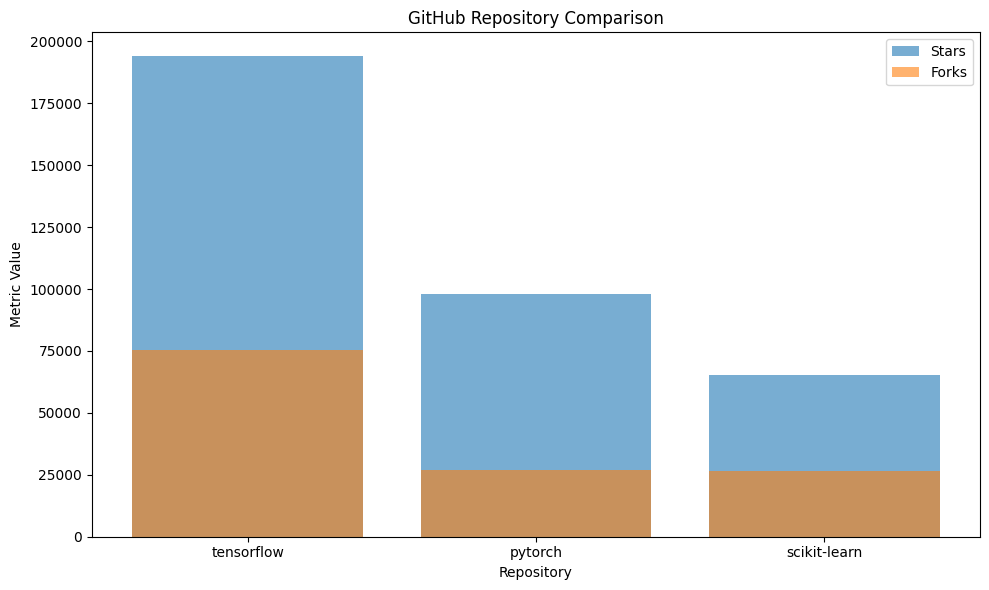

task1_comparison.png saved successfully ✓


In [17]:
import matplotlib.pyplot as plt

def task1_visualization():
    df = pd.read_csv('task1_metrics.csv')
    
    plt.figure(figsize=(10,6))
    
    x = df['name']
    
    plt.bar(x, df['stars'], alpha=0.6, label='Stars')
    plt.bar(x, df['forks'], alpha=0.6, label='Forks')
    
    plt.title("GitHub Repository Comparison")
    plt.xlabel("Repository")
    plt.ylabel("Metric Value")
    plt.legend()
    
    plt.tight_layout()
    plt.savefig("task1_comparison.png")
    plt.show()
    
    print("task1_comparison.png saved successfully ✓")

task1_visualization()

**1.2** *(5 points)* For each repo, calculate:
- **Age in days** (from `created_date` to now)
- **Stars per day**
- **Issues per star ratio**

Save as: **`task1_metrics.csv`**

**1.3** *(5 points)* Create a **visualization** comparing the three repositories:
- Save as: **`task1_comparison.png`**
- Use `matplotlib` or `seaborn`
- Compare **at least 3 metrics**

---

### 📋 Task 2: User Repository Analysis *(20 points)*

**2.1** *(10 points)* Choose any GitHub user and fetch **ALL** their repositories (handle pagination)

Requirements:
- Implement **pagination** properly
- Add **rate limiting** (wait 1 second between requests)
- Handle errors gracefully
- Log progress

Save as: **`task2_all_repos.csv`**

In [18]:
def fetch_user_repos_paginated(username):
    """
    Fetch all repositories for a user with pagination.

    Args:
        username: GitHub username

    Returns:
        list: All repositories
    """
    all_repos = []
    page = 1
    while True:

        print(f"Fetching page {page}...")

        params = {'page': page, 'per_page': 100} 

        url = f'https://api.github.com/users/{username}/repos'
        try:
            response = requests.get(url, params=params)

            if response.status_code != 200:
                print(f"Error: {response.status_code}")
                break

            data = response.json()

            if not data or len(data) == 0:
                print("No more results!")
                break

            for repo in data:
                repo_data = {
                    "name": repo["name"],
                    "stars": repo["stargazers_count"],
                    "forks": repo["forks_count"],
                    "language": repo["language"],
                    "created_at": repo["created_at"],
                    "open_issues": repo["open_issues_count"]
                }
                
                all_repos.append(repo_data)

            page += 1
            time.sleep(1)

        except Exception as e:
            print(f"Exception occurred: {e}")
            break

        return pd.DataFrame(all_repos)

    # Your implementation here
    # Remember to:
    # 1. Check for empty responses  --> means you've hit the last page
    # 2. Add delays                 --> time.sleep(1) to be polite
    # 3. Handle errors              --> try/except around requests
    # 4. Log progress               --> print or logger.info(f"Page {page}")

    return all_repos

df = fetch_user_repos_paginated("torvalds")
df.to_csv("task2_all_repos.csv", index=False)

Fetching page 1...


In [19]:
import pandas as pd

def analyze_user_repos():
    df = pd.read_csv("task2_all_repos.csv")

    if df.empty:
        print("No data available for analysis.")
        return

    df["created_at"] = pd.to_datetime(df["created_at"])
    if "updated_at" in df.columns:
        df["updated_at"] = pd.to_datetime(df["updated_at"])
    else:
        df["updated_at"] = df["created_at"]

    most_used_language = df["language"].value_counts().idxmax()

    avg_stars = df["stars"].mean()

    total_forks = df["forks"].sum()

    most_recent_repo = df.loc[df["updated_at"].idxmax(), "name"]

    oldest_repo = df.loc[df["created_at"].idxmin(), "name"]

    report = f"""
GitHub Repository Analysis Report
==================================

Total Repositories: {len(df)}

Most Used Programming Language: {most_used_language}
Average Stars per Repository: {avg_stars:.2f}
Total Forks Across All Repositories: {total_forks}

Most Recently Updated Repository: {most_recent_repo}
Oldest Repository: {oldest_repo}
"""

    with open("task2_analysis.txt", "w", encoding="utf-8") as f:
        f.write(report)   


analyze_user_repos()

**2.2** *(10 points)* Analyze the repositories:
- Most used **programming language**
- **Average stars** per repository
- **Total forks** across all repos
- **Most recently updated** repo
- **Oldest** repo

Create a summary report saved as: **`task2_analysis.txt`**

---

### 📋 Task 3: Advanced API Client *(15 points)*

**3.1** *(15 points)* Build a complete `GitHubAnalyzer` class

Requirements:
- **Inherit from** or include rate limiting
- Implement **retry logic** with exponential backoff
- Add **logging**
- Include these methods:
  - `search_repos(query, language, min_stars)` — Search repositories
  - `get_trending(language, since)` — Get trending repos
  - `compare_repos(repo_list)` — Compare multiple repos
  - `export_to_excel(df, filename)` — Export with formatting

In [20]:
from datetime import datetime, timedelta

In [23]:
class GitHubAnalyzer:
    """
    Complete GitHub API client with analysis capabilities.
    Build on top of the GitHubAPI class concepts from section 2.7.
    """

    def __init__(self, token=None):
        # Your initialization
        # Hint: Set up session, rate_limiter, logger like in GitHubAPI
        logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s - %(levelname)s - %(message)s"
        )
        self.logger = logging.getLogger(self.__class__.__name__)

        self.base_url = 'https://api.github.com'
        self.session = self._create_session()
        self.rate_limiter = RateLimiter(
            max_requests=5000, time_window=3600
        ) 

        if token:
            self.session.headers.update({'Authorization': f'Bearer {token}'})

        self.session.headers.update(
            {
                'Accept': 'application/vnd.github.v3+json',
                'User-Agent': 'Library-Tutorial/1.0',
            }
        )


    def _create_session(self):
        """Create session with retry logic (private method)."""
        session = requests.Session()
        retry_strategy = Retry(
            total=5, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504],allowed_methods=["GET"]
        )
        adapter = HTTPAdapter(max_retries=retry_strategy)
        session.mount("http://", adapter)
        session.mount("https://", adapter)
        return session
    
    def get_trending(self, language="Python", since=7):
        """
        Get trending repositories.
        Trending = most starred repos created in the last `since` days.

        Args:
            language: Programming language
            since: Number of days back

        Returns:
            DataFrame
        """    
        date_since = (
            datetime.utcnow() - timedelta(days=since)
        ).strftime("%Y-%m-%d")

        query = f"language:{language} created:>={date_since}"

        results = self.get(
            "/search/repositories",
            params={
                "q": query,
                "sort": "stars",
                "order": "desc",
                "per_page": 30
            }
        )

        items = results.get("items", [])

        data = []
        for repo in items:
            data.append({
                "name": repo["full_name"],
                "stars": repo["stargazers_count"],
                "forks": repo["forks_count"],
                "language": repo["language"],
                "created_at": repo["created_at"]
            })

        return pd.DataFrame(data)

    def get(self, endpoint, params=None):
        """Make GET request with rate limiting."""
        self.rate_limiter.wait_if_needed()  # Respect rate limits
        url = f"{self.base_url}/{endpoint.lstrip('/')}"

        try:
            response = self.session.get(url, params=params, timeout=10)
            response.raise_for_status()  # Raises exception for 4xx/5xx
            self.logger.info(f"GET {endpoint} - Status: {response.status_code}")

            # Peek at remaining rate limit with each response
            remaining = check_rate_limit(response)
            return response.json()

        except Exception as e:
            self.logger.error(f"Error fetching {endpoint}: {e}")
            raise

    def search_repos(self, query, language=None, min_stars=0):
        """
        Search repositories with filters.

        Returns:
            DataFrame with results
        """
        q_parts = [query]
        if language:
            q_parts.append(f"language:{language}")
        if min_stars:
            q_parts.append(f"stars:>={min_stars}")

        q = ' '.join(q_parts)
        results = self.get('/search/repositories', params={
            "q": q,
            "sort": "stars",
            "order": "desc",
            "per_page": 30
        })
        items = results.get("items", [])

        data = []
        for repo in items:
            data.append({
                "name": repo["full_name"],
                "stars": repo["stargazers_count"],
                "forks": repo["forks_count"],
                "language": repo["language"],
                "created_at": repo["created_at"],
                "updated_at": repo["updated_at"]
            })

        return pd.DataFrame(data)

    def compare_repos(self, repo_list):
        """
        Compare multiple repositories.

        Args:
            repo_list: List of "owner/repo" strings

        Returns:
            DataFrame with comparison
        """
        comparison_data = []

        for repo in repo_list:
            try:
                data = self.get(f"/repos/{repo}")

                comparison_data.append({
                    "name": data["full_name"],
                    "stars": data["stargazers_count"],
                    "forks": data["forks_count"],
                    "open_issues": data["open_issues_count"],
                    "watchers": data["watchers_count"],
                    "language": data["language"],
                    "created_at": data["created_at"],
                    "updated_at": data["updated_at"]
                })

            except Exception as e:
                self.logger.error(f"Failed to fetch {repo}: {e}")
                continue

        return pd.DataFrame(comparison_data)

    def export_to_excel(self, df, filename):
        """
        Export DataFrame to Excel with formatting.
        - Bold headers
        - Auto-adjust column widths
        - Add creation timestamp
        """
        with pd.ExcelWriter(filename, engine="xlsxwriter") as writer:
            df.to_excel(writer, sheet_name="Results", index=False)

            workbook = writer.book
            worksheet = writer.sheets["Results"]

            header_format = workbook.add_format({
                "bold": True,
                "text_wrap": True,
                "valign": "middle"
            })

            for col_num, value in enumerate(df.columns.values):
                worksheet.write(0, col_num, value, header_format)

                column_len = max(
                    df[value].astype(str).map(len).max(),
                    len(value)
                ) + 2
                worksheet.set_column(col_num, col_num, column_len)

            worksheet.write(len(df) + 2, 0,
                            f"Exported at: {datetime.now()}")

        self.logger.info(f"{filename} exported successfully")


# Test your class by:
# 1. Searching for "data science" repos in Python with >500 stars
# 2. Comparing 5 repos of your choice
# 3. Exporting results to task3_results.xlsx

analyzer = GitHubAnalyzer()

search_df = analyzer.search_repos(
    query="data science",
    language="Python",
    min_stars=500
)

print(search_df.head())

trending_df = analyzer.get_trending(language="Python", since=7)
print(trending_df.head())

repos_to_compare = [
    "tensorflow/tensorflow",
    "pytorch/pytorch",
    "scikit-learn/scikit-learn",
    "keras-team/keras",
    "apache/spark"
]

compare_df = analyzer.compare_repos(repos_to_compare)

print(compare_df)

analyzer.export_to_excel(compare_df, "task3_results.xlsx")

2026-03-02 14:50:01,034 - GitHubAnalyzer - INFO - GET /search/repositories - Status: 200
C:\Users\ASM EL Masrya\AppData\Local\Temp\ipykernel_13976\1845071880.py:57: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  datetime.utcnow() - timedelta(days=since)


Rate Limit: 9/10
Resets at: 2026-03-02 14:50:59
⚠️ Warning: Low on API requests!
                                         name  stars  forks language  \
0  donnemartin/data-science-ipython-notebooks  28900   8033   Python   
1                             kedro-org/kedro  10771   1011   Python   
2                            OpenMined/PySyft   9857   2007   Python   
3     drivendataorg/cookiecutter-data-science   9700   2628   Python   
4          joelgrus/data-science-from-scratch   9512   4723   Python   

             created_at            updated_at  
0  2015-01-23T19:38:29Z  2026-03-02T06:06:31Z  
1  2019-04-18T10:29:56Z  2026-02-27T16:53:26Z  
2  2017-07-18T20:41:16Z  2026-02-28T12:22:06Z  
3  2015-10-30T19:19:57Z  2026-03-02T10:20:44Z  
4  2014-11-09T02:31:24Z  2026-03-01T15:51:21Z  


2026-03-02 14:50:02,071 - GitHubAnalyzer - INFO - GET /search/repositories - Status: 200


Rate Limit: 8/10
Resets at: 2026-03-02 14:50:59
⚠️ Warning: Low on API requests!
                                    name  stars  forks language  \
0  anthropics/financial-services-plugins   5145    518   Python   
1                    agentscope-ai/CoPaw   4657    467   Python   
2                Panniantong/Agent-Reach   3715    294   Python   
3                     Lakr233/vphone-cli   2326    417   Python   
4                  peteromallet/dataclaw   1751    214   Python   

             created_at  
0  2026-02-23T19:24:50Z  
1  2026-02-24T03:42:56Z  
2  2026-02-24T02:10:24Z  
3  2026-02-26T11:29:08Z  
4  2026-02-24T20:33:55Z  


2026-03-02 14:50:02,473 - GitHubAnalyzer - INFO - GET /repos/tensorflow/tensorflow - Status: 200


...

Rate Limit: 18/60
Resets at: 2026-03-02 15:16:38


2026-03-02 14:50:03,813 - GitHubAnalyzer - INFO - GET /repos/keras-team/keras - Status: 200


Rate Limit: 17/60
Resets at: 2026-03-02 15:16:38


2026-03-02 14:50:04,216 - GitHubAnalyzer - INFO - GET /repos/apache/spark - Status: 200
2026-03-02 14:50:04,300 - GitHubAnalyzer - INFO - task3_results.xlsx exported successfully


Rate Limit: 16/60
Resets at: 2026-03-02 15:16:38
                        name   stars  forks  open_issues  watchers language  \
0      tensorflow/tensorflow  193960  75215         3594    193960      C++   
1            pytorch/pytorch   97880  27034        18060     97880   Python   
2  scikit-learn/scikit-learn   65267  26737         2147     65267   Python   
3           keras-team/keras   63887  19713          292     63887   Python   
4               apache/spark   42909  29083          255     42909    Scala   

             created_at            updated_at  
0  2015-11-07T01:19:20Z  2026-03-02T12:43:15Z  
1  2016-08-13T05:26:41Z  2026-03-02T12:26:45Z  
2  2010-08-17T09:43:38Z  2026-03-02T12:00:55Z  
3  2015-03-28T00:35:42Z  2026-03-02T09:05:10Z  
4  2014-02-25T08:00:08Z  2026-03-02T06:32:43Z  


---
## 📦 Submission Requirements

### Files to submit:

| # | File | Description |
|---|---|---|
| 1 | `github_analysis.py` | All your code |
| 2 | `task1_github.csv` | Repo info table |
| 3 | `task1_metrics.csv` | Calculated metrics |
| 4 | `task1_comparison.png` | Visualization |
| 5 | `task2_all_repos.csv` | All user repos |
| 6 | `task2_analysis.txt` | Summary report |
| 7 | `task3_results.xlsx` | Excel export |
| 8 | `api_requests.log` | Your log file |
| 9 | `README.md` | Brief report of findings |

---

### 📊 Grading Rubric:

| Category | Weight |
|---|---|
| **Correct functionality** | 60% |
| **Code quality** (comments, error handling, logging) | 20% |
| **Output formatting** | 10% |
| **Analysis insights** | 10% |